In [55]:
import torch
from torch import nn
from matplotlib import pyplot as plt
import torch.nn.functional as F
from d2l import torch as d2l
from torch.utils.data import DataLoader, TensorDataset
import pandas as pd
import numpy as np
import os

In [56]:
class MatrixFac(nn.Module):
    def __init__(self, user, item, k, **kwargs):
        super(MatrixFac, self).__init__(**kwargs)
        self.user_num = user
        self.item_num = item
        self.latent_dim = k
        self.user_mat = nn.Embedding(user, k)
        self.item_mat = nn.Embedding(item, k)
        self.user_bias = nn.Embedding(user, 1)
        self.item_bias = nn.Embedding(item, 1)

    def forward(self, user, item):
        user_mat = self.user_mat(user)
        item_mat = self.item_mat(item)
        
        user_bias = self.user_bias(user).squeeze()
        item_bias = self.item_bias(item).squeeze()

        rate = (user_mat * item_mat).sum(dim=1) + user_bias + item_bias

        return rate.flatten()
        

In [57]:
def evaluator(net, test_iter, device):
    net.eval()
    total_squared_error = 0
    total_samples = 0

    with torch.no_grad():
        for (user, item, rate) in test_iter:
            user = user.to(device)
            item = item.to(device)
            rate = rate.to(device)
            
            rate_hat = net(user, item)

            total_squared_error += F.mse_loss(rate_hat, rate, reduction='none').sum(dim=0).item()
            total_samples += rate.shape[0]

    rmse = torch.sqrt(torch.tensor(total_squared_error / total_samples))
    return float(rmse)

In [58]:
def train_recsys_rating(net, train_iter, test_iter, epochs, trainer, device, loss, evaluator=None, **kwargs):
    net = net.to(device)
    timer = d2l.Timer()
    fig, ax = plt.subplots(1, 2)
    loss_curv = []
    num_epochs = [i for i in range(epochs)]

    for epoch in range(epochs):
        metric = d2l.Accumulator(4)
        net.train()
        loss_epoch = 0

        for i, values in enumerate(train_iter):
            trainer.zero_grad()
            values = [v.to(device) for v in values]

            train_feats = values[:-1]
            train_label = values[-1]

            preds = net(*train_feats)

            l = loss(preds, train_label) 

            l.backward()
            trainer.step()

            batch_size = train_label.shape[0]
            metric.add(l.item() * batch_size, batch_size, train_label.numel())
            timer.stop() 
            loss_epoch += l.item() * batch_size

        if len(kwargs) > 0:              
            test_rmse = evaluator(net, test_iter, kwargs['inter_mat'], device)
        else:
            test_rmse = evaluator(net, test_iter, device) 

        train_l = metric[0] / metric[1]
        loss_curv.append(loss_epoch / metric[1])

    ax[0].plot(num_epochs, loss_curv)
    fig.show()

    print(f'train_loss: {train_l:.3f}\n')
    print(f'test_rmse: {test_rmse:.3f}\n')
    print(f'{metric[2] * epochs / timer.sum():.1f} example / sec\n')


In [59]:
d2l.DATA_HUB['ml-100k'] = (
    'https://files.grouplens.org/datasets/movielens/ml-100k.zip',
    'cd4dcac4241c8a4ad7badc7ca635da8a69dddb83')

#@save
def read_data_ml100k():
    data_dir = d2l.download_extract('ml-100k')
    names = ['user_id', 'item_id', 'rating', 'timestamp']
    data = pd.read_csv(os.path.join(data_dir, 'u.data'), sep='\t',
                       names=names, engine='python')
    num_users = data.user_id.unique().shape[0]
    num_items = data.item_id.unique().shape[0]
    return data, num_users, num_items

In [60]:
def split_data_ml100k(data, num_users, num_items, split_mode='random', test_ratios=0.1):
    if (split_mode == 'seq_aware'):
        train_items, test_items, train_list = {}, {}, []
        for line in data.itertuples():
            u, i, rating, time = line[0], line[1], line[2], line[3]
            train_items.setdefault(u, []).append((u, i, rating, time))
            if u not in test_items or test_items[u][-1] < time:
                test_items[u] = (i, rating, time)

        for u in range(1, num_users + 1):
            train_list.extend(sorted(train_items[u], key=lambda k: k[3]))
        test_data = [(key, *values) for key, values in test_items.items()]
        train_data = [item for item in train_items.items() if item not in test_data]
        train_data = pd.DataFrame(train_data)
        test_data = pd.DataFrame(test_data)
    else:
        mask = [True if x == 1 else False for x in np.random.uniform(0, 1, (len(data))) < 1 - test_ratios]
        neg_mask = [not i for i in mask]
        train_data, test_data = data[mask], data[neg_mask]

    return train_data, test_data

In [ ]:
def load_data_ml100k(data, num_users, num_items, feedback='explicit'):
    users, items, scores = [], [], []
    inter = np.zeros((num_items, num_users)) if feedback == 'explicit' else {}
    for line in data.itertuples():
        user_index, item_index = int(line[1] - 1), int(line[2] - 1)
        score = int(line[3]) if feedback == 'explicit' else 1
        users.append(user_index)
        items.append(item_index)
        scores.append(score)

        if feedback != 'explicit':
            inter.setdefault(user_index, []).append(item_index)
        else:
            inter[item_index][user_index] = score

    return users, items, scores, inter

In [62]:
def split_and_load_ml100k(split_mode='seq-aware', feedback='explicit',
                          test_ratio=0.1, batch_size=256):
    data, num_users, num_items = read_data_ml100k()
    train_data, test_data = split_data_ml100k(
        data, num_users, num_items, split_mode, test_ratio)
    train_u, train_i, train_r, _ = load_data_ml100k(
        train_data, num_users, num_items, feedback)
    test_u, test_i, test_r, _ = load_data_ml100k(
        test_data, num_users, num_items, feedback)

    train_u = torch.tensor(train_u, dtype=torch.long)
    train_i = torch.tensor(train_i, dtype=torch.long)
    train_r = torch.tensor(train_r, dtype=torch.float32)

    test_u = torch.tensor(test_u, dtype=torch.long)
    test_i = torch.tensor(test_i, dtype=torch.long)
    test_r = torch.tensor(test_r, dtype=torch.float32)

    train_set = TensorDataset(
       train_u, train_i, train_r 
    )
    
    test_set = TensorDataset(
       test_u, test_i, test_r 
    )

    train_iter = DataLoader(train_set, batch_size=batch_size, shuffle=True, drop_last=False)
    test_iter = DataLoader(test_set, batch_size=batch_size, shuffle=False)
    
    return num_users, num_items, train_iter, test_iter

train_loss: 18.294

test_rmse: 4.686

130.1 example / sec



C:\Users\a9364\AppData\Local\Temp\ipykernel_6632\2284341167.py:41: UserWarning: Matplotlib is currently using module://matplotlib_inline.backend_inline, which is a non-GUI backend, so cannot show the figure.
  fig.show()


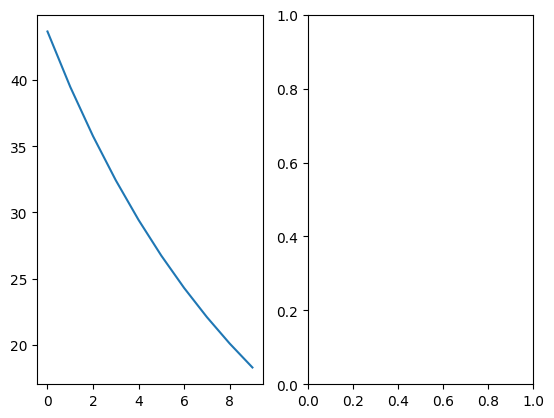

In [63]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
learning_rate = 1e-3
weight_decay = 1e-5 
epochs = 10
num_users, num_items, train_iter, test_iter = split_and_load_ml100k(test_ratio=0.1, batch_size=512)
net = MatrixFac(num_users, num_items, 30)
trainer = torch.optim.Adam(params=net.parameters(), lr=learning_rate, weight_decay=weight_decay)

train_recsys_rating(net, train_iter, test_iter, epochs, trainer, device, F.mse_loss, evaluator)